In [33]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import os
import random
import pathlib
import re
import numpy as np
import pandas as pd
import tensorflow as tf
import uuid
import cv2
import os
import shutil
import albumentations as A
import tensorflow as tf
from tensorflow.keras.models import model_from_json
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
# import dash
# from dash import dcc, html
# from dash.dependencies import Input, Output
from matplotlib import pyplot as plt

# Tensorflow
import tensorflow as tf
from tensorflow import keras
from keras import metrics as metrics


metrics=[ tf.metrics.CategoricalAccuracy(name="acc"),
      tf.keras.losses.CategoricalCrossentropy(name='loss'),
      tf.keras.metrics.F1Score(average="macro", threshold=None, name='f1_score'),
      tf.metrics.Precision(name='precision'),
      tf.metrics.Recall(name='recall')]

train_paths=r"/kaggle/input/train-val-plant/train/content/drive/MyDrive/ColabNotebooks/Datas/Plantvilage_that_we_will_use"
val_paths=r"/kaggle/input/train-val-plant/val/content/drive/MyDrive/ColabNotebooks/Datas/V_plant"
test_paths=r"/kaggle/input/train-val-plant/test/content/drive/MyDrive/ColabNotebooks/Datas/T_plant"

In [34]:
!nvidia-smi
device_name = tf.test.gpu_device_name()

print('Found GPU at: {}'.format(device_name))

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))


from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

tf.__version__

Sat Aug 16 00:00:59 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P0             32W /  250W |   15805MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

I0000 00:00:1755302459.757375      35 gpu_device.cc:2022] Created device /device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


'2.18.0'

This cell includes functions to help us
* Explore
* Describe
* Organise
* Engineer
Our data.
### Parsing of the path and creating the DataFrame

# Function __parse_root__ includes

  *   Fuction ***extract_plant_names*** seperates the Folder string names      into 2 new Series based on a **regex** pattern:

    *   Plants
    *   Sudirectory Names: Disease or Healty

  * Function __clasify_folders__ that classifies folder depended on the mean value:
    *   Above mean
    *   Below mean
    *   Risk

  * Function __meta_data__ responsible of updating a dataframe based on metrics and will include:
    * Split amount for the different splits
    * Total Files that remain after the split
    * Augmented images we need to reach the value we want
    * How many original images we need to augment

Function __Describe_Models__ responsible to:
Receives a list of models. Unpack each model and store the data of each layer.
Stored info is a __dataframe__ of:
  * Model name
  * Layer name
  * Score (value of the layer)
  * Label (which is th numerical count of eeach model layer)

In [36]:
def extract_plant_names(folder_names, pattern):
    """
    Extract plant names from folder names using a regex pattern.
    Alerts for any unmatched folder names.

    Parameters:
        folder_names (list): List of folder names to process.
        pattern (str): Regex pattern to extract plant names.

    Returns:
        plant_names (list): List of extracted plant names.
        sub_names (list): List of the folder names with out the plant string.
    """
    plant_names = []
    unmatched = []
    sd_names = []

    for folder in folder_names:
        match = re.match(pattern, folder)
        if match:
            plant_name = match.group(1)
            sd_name = folder.split("___")[1]  # Assuming "___" separates the plant and the second name
            plant_names.append(plant_name)
            sd_names.append(sd_name)
        else:
            plant_names.append("Unknown")
            sd_names.append("Unknown")
            unmatched.append(plant_names)

    # Alert for unmatched folder names
    if unmatched:
        print("⚠️ Alert: The following folder names did not match the expected pattern:")
        for folder in unmatched:
            print(f"- {folder}")

    return plant_names,sd_names


def classify_folders(counts):
    """
    Categorizes numerical counts into:
      - 'Above_mean' (counts => mean)
      - 'Below_mean' (half_mean ≤ counts ≤ mean)
      - 'Risk' (counts < half_mean)

    Returns a NumPy array of category labels.
    """
    mean_value = int(counts.mean())
    half_mean = mean_value // 2  # Ensure integer division consistency


    print(f"Mean: {mean_value}, Half Mean: {half_mean}")

    return np.select(
        [counts >= mean_value, counts >= half_mean],
        ["Above_mean", "Below_mean"],
        default="Risk"
    )


def meta_data(folder_counts):
  mean_value = int(folder_counts["Counts"].mean())

  # Anything that is" not in Risk will have 100 items the rest will be 200 items for validation and test
  folder_counts["split_size"] = np.where(folder_counts["MeanCategory"] != "Risk", 200, 100)

  # Compute the number of images available for training after the split
  folder_counts["train_files"] = folder_counts["Counts"] - (folder_counts["split_size"]*2)
  # we cut down the Above_mean category
  folder_counts.loc[folder_counts["MeanCategory"] == "Above_mean", "train_files"] = mean_value // 2

  # Compute the number of images that we need to compensate with augmentation
  folder_counts["Augment_Needed"] = np.maximum(0, mean_value - folder_counts["train_files"])

  # Compute the number of distinct images required for augmentation (rounded up)
  folder_counts["original_files"] = np.ceil(folder_counts["Augment_Needed"] / 15).astype(int)
  return folder_counts

def parse_root(root,pattern = r'^([^_]+)',remove=None):
    """Parse dataset folder structure and build a dataframe with metadata."""


    p = pathlib.Path(root)
    dist_files = {
        folder.name: [file for file in folder.iterdir()]
        for folder in p.iterdir() if folder.is_dir()
    }
    # Count files in each folder
    folder_counts = pd.DataFrame({
        'Folder': dist_files.keys(),
        'Counts': [len(v) for v in dist_files.values()]
    })

    if remove is None:
      remove=['Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot','Tomato___Tomato_Yellow_Leaf_Curl_Virus',
        'Apple___Cedar_Rust','Tomato___Tomato_mosaic_virus','Potato___Early_blight','Potato___Late_blight','Potato___healthy',"Soybean___healthy","Blueberry___healthy","Orange___Haunglongbing_(Citrus_greening)","Raspberry___healthy","Squash___Powdery_mildew"]
      folder_counts.drop(folder_counts[folder_counts['Folder'].isin(remove)].index,inplace=True)
    # fldoer_counts = folder_counts.drop(columns=[key for key in remove if key in folder_counts])
      folder_counts.reset_index(drop=True, inplace=True)

    folder_counts['Plants'], folder_counts['Sub'] = extract_plant_names(folder_counts['Folder'],pattern)
    folder_counts['MeanCategory'] = classify_folders(folder_counts['Counts'])
    folder_counts = meta_data(folder_counts)

    return folder_counts, dist_files


def distribute_data(df, dist_files):

  """" Creates splits of train,validation and iamge file paths and take some to be augmented.
      Based on the metadata we transform the split strategy and provide sets of files to be used.

  """

  train, validation, test, aug_train = {}, {}, {}, {}
  for _, row in df.iterrows():
    folder = row["Folder"]
    available_files = dist_files.get(folder, []).copy()

    # Shuffle to ensure randomness
    random.shuffle(available_files)

    # Extract necessary values
    split_size = row["split_size"]  # Now dynamically assigned per category
    distinct_aug_sources = int(row["original_files"])  # Available distinct images
    # For each key : Folder Name

    # 1) Allocate test set
    test[folder], available_files = available_files[:split_size], available_files[split_size:]

    # 2) Allocate validation set
    validation[folder], available_files = available_files[:split_size], available_files[split_size:]

    # 3) Reserve originals for augmentation (only if augment=True)
    aug_train[folder], available_files = available_files[:distinct_aug_sources], available_files[distinct_aug_sources:]

    train[folder] = available_files

  return train, validation, test, aug_train


def describe_model(models):
    """
    Recursively gather layers info from a final model, *but*:
      - For the base model (like MobileNetV2), retrieve the base model name as a string in a separate column.
        (No expansion of base layers)
      - For the 'head' model (e.g., a Sequential), skip the top-level name, but store each sub-layer
        (Dense/Dropout, etc.).

    Returns a list of tuples: (model_label, layer_name, attribute_value, base_model_string).
    """

    if isinstance(models, tf.keras.Model):
        models = [models]

    all_info = []

    def store_info(label, layer_obj, base_model_str=None):
        """
        Extract attribute from layer_obj (units, filters, rate) if present.
        Return a tuple (label, layer_name, attr_val, base_model_str).
        """
        if hasattr(layer_obj, 'units'):
            attr_val = layer_obj.units
        elif hasattr(layer_obj, 'filters'):
            attr_val = layer_obj.filters
        elif hasattr(layer_obj, 'rate'):
            attr_val = layer_obj.rate
        else:
            attr_val = None

        return (label, layer_obj.name, attr_val, base_model_str)

    def is_base_model(layer):
        """
        Heuristic check: if layer is a Keras Model and it's one of the known
        pretrained application names or typically has 'mobilenetv2', 'resnet50', etc. in the name,
        we treat it as the 'base model.'
        """
        if isinstance(layer, tf.keras.Model):
            if any(k.lower() in layer.name.lower() for k in ["mobilenetv2", "resnet50","EfficientNetB0"]):
                return True
        return False

    def expand_layers(layer_list, parent_label="", base_model_str=None):
        """
        For each layer in layer_list:
          - If it's the 'base model', remember its name for all following layers.
          - If it's a sub-model (not base), expand it recursively.
          - Otherwise, store the layer info including base_model_str.
        """
        for layer in layer_list:
            if is_base_model(layer):
                base_model_str = layer.name
            elif isinstance(layer, tf.keras.Model):
                expand_layers(layer.layers, parent_label=parent_label, base_model_str=base_model_str)
            else:
                info = store_info(parent_label, layer, base_model_str)
                all_info.append(info)

    for model_obj in models:
        expand_layers(model_obj.layers, parent_label=model_obj.name)

    return layer_info_to_df(all_info)


def layer_info_to_df(layer_info):
    """
    layer_info : list of tuples [(model_label, layer_name, attr_val, base_model_string), ...]
    Returns a DataFrame with columns: [model name, layer name, score, base model]
    """
    df = pd.DataFrame(layer_info, columns=["model name", "layer name", "score", "base model"])

    # Clean trailing digits from layer names (optional)
    df['layer name']=df['layer name'].apply(lambda x: re.sub(r'_.*', '', x))

    # Generate unique label where layer name is not null

    df['label'] = (
        df.groupby(['model name', 'layer name'])
        .cumcount()
        .astype(str)
        .radd(df['layer name'] + '_'))

    df.dropna(inplace=True)

    return df




In [ ]:

# weather = A.Compose([
#      A.RandomSnow(brightness_coeff=1.7,  snow_point_range= (0.3,0.5),p=0.5),
#      A.RandomRain(brightness_coefficient=0.8, drop_width=2, blur_value=3, p=0.5)
#  ])

# light = A.Compose([
#     # A. RandomBrightnessContrast(brightness_limit=(-0.23,0.35),p=0.5),
#     A.GridDropout(ratio=0.3,p=0.5),
#     A.MultiplicativeNoise(multiplier=(0.97,2.30),elementwise=True,per_channel=True,p=0.5)
# ])

# geometric = A.Compose([
#      A.CLAHE(p=1),
#      A.HorizontalFlip(p=0.5),
#      A.VerticalFlip(p=0.5)

# ])

# def Aug(img_path,loops):
#     """
#     Load one image with Keras, then produce 16 images:
#       1 original + 15 augmented (5 loops × 3 pipelines).
#     Each returned image is np.uint8 in [0..255].
#     Shape is consistent with the original loaded image.
#     """
#     pil_img = tf.keras.utils.load_img(img_path, color_mode='rgb')
#     base_arr = np.array(pil_img, dtype=np.uint8)

#     aug_list = [base_arr]  # keep original
#     sshape = base_arr.shape  # (H, W, 3)

#     for _ in range(loops):
#         w = weather(image=base_arr)['image']
#         l = light(image=base_arr)['image']
#         g = geometric(image=base_arr)['image']
#         for arr in [w, l, g]:
#             if arr.shape != sshape:
#                 arr = np.resize(arr, sshape)
#             aug_list.append(arr)

#     return aug_list


# def build_dataset_from_dict(
#     data_dict,
#     target_size= None,
#     to_augment= None,
#     loops= 5) -> tf.data.Dataset:


#     def parse_record(file_path, label_str):
#         """
#         - file_path: tf.string path to the image file
#         - label_str: tf.string label
#         """
#         # Read file from disk
#         image_bytes = tf.io.read_file(file_path)

#         # Decode image (handles PNG, JPEG, etc.), expand_animations=False ensures a single image
#         img = tf.io.decode_image(image_bytes, channels=3)
#         # Now img has shape [height, width, 3], dtype=uint8 in [0..255]

#         # Convert to float [0..1], then resize
#         img = tf.image.convert_image_dtype(img, tf.float32)
#         img.set_shape([None, None, 3])
#         if target_size is not None:
#           img = tf.image.resize(img, target_size)  # (H, W, 3)
#         return img, label_str


#      #  make (file_path, label)  Flatten dict -> (files, labels)
#     def flatten_dict(d):
#         # Create two parallel lists
#         file_paths = []
#         labels = []
#         for lbl, paths in d.items():
#             for p in paths:
#                 file_paths.append(str(p))
#                 labels.append(lbl)
#         return file_paths, labels

#     normal_files, normal_labels = flatten_dict(data_dict)
#     # 2) Create dataset from these records and process it
#     ds = tf.data.Dataset.from_tensor_slices((normal_files,normal_labels))
#     ds = ds.map(parse_record, num_parallel_calls=tf.data.AUTOTUNE)

#     if not to_augment:
#         return ds

#     # -- streaming generator for AUGMENTED images -------------
#     def gen():
#         for lbl, paths in to_augment.items():
#             for p in paths:
#                 for arr in Aug(p, loops=loops):
#                     yield arr, lbl

#     ds_aug = tf.data.Dataset.from_generator(
#         gen,
#         output_signature=(
#             tf.TensorSpec(shape=(None, None, 3), dtype=tf.uint8),
#             tf.TensorSpec(shape=(),              dtype=tf.string),
#         ))


#     # scale uint8→float32, resize
#     def scale_uint8(img_u8, label):
#         img = tf.image.convert_image_dtype(img_u8, tf.float32)
#         img.set_shape([None, None, 3])
#         label = tf.cast(label, tf.string)
#         if target_size is not None:
#           img = tf.image.resize(img, target_size)  # (H, W, 3)
#         return img, label

#     ds_aug = ds_aug.map(scale_uint8, num_parallel_calls=tf.data.AUTOTUNE)

#     # -- merge & return --------------------------------------
#     ds_final=ds.concatenate(ds_aug)
#     return ds_final



In [ ]:

# n=df["Folder"].to_list()
# train_dataset=build_dataset_from_dict(data_dict=train,to_augment=aug)
# print("Element spec:", train_dataset.element_spec)

# for imgs, lbls in train_dataset.take(1):
#     print("Batch image tensor shape:", imgs.shape)   # (batch, 224, 224, 3)
#     print("Batch labels:", lbls.numpy())




# string_lookup = tf.keras.layers.StringLookup(
#                     vocabulary      = n,
#                     output_mode     = "one_hot",
#                     num_oov_indices = 0)

# train_dataset= train_dataset.map(
#     lambda img, lbl: (
#         img,
#         tf.squeeze(                      # remove length‑1 middle axis
#             tf.cast(string_lookup(lbl), tf.float32),
#             axis=-2                      # or axis=1 (same thing here)
#         )
#     ),
#     num_parallel_calls=tf.data.AUTOTUNE
# )


# train_dataset = (train_dataset
#                   .shuffle(1024)
#                   .batch(BATCH)
#                   .prefetch(tf.data.AUTOTUNE))

# val_dataset=build_dataset_from_dict(data_dict=val)
# val_dataset= val_dataset.map(
#     lambda img, lbl: (
#         img,
#         tf.squeeze(                      # remove length‑1 middle axis
#             tf.cast(string_lookup(lbl), tf.float32),
#             axis=-2                      # or axis=1 (same thing here)
#         )
#     ),
#     num_parallel_calls=tf.data.AUTOTUNE
# )

# val_dataset = (val_dataset
#                   .batch(BATCH)
#                   .prefetch(tf.data.AUTOTUNE))

# Here we will use a fast way of defining and creating models based on base modes and functions as classification heads.

1. Group with heads of **head_b_256_d_128_64 & head_b_256_d_128_64_d**,
   will anwser the questions:
   *  How significant will be the change of adding a **Dropout** layer before the softmax?
   *  How sigificat will be the chage of avoiding the **Batch Norm** after the GlobalMax ad what's the change if we unfreeze the **BatchNorms** of the base model <-- TODO
2. Group with heads of **head_b_256_d_128_d_128_d & head_b_256_d_128_128_d** , will answer the question of incresig the depth or width of the model with an idermidiate dropout

In [37]:
# df,dist=parse_root('/kaggle/input/plantvillage-dataset/color')
# print(df.head())
# train,val,test,aug=distribute_data(df, dist)
size=224
BATCH=256
df_data=parse_root('/kaggle/input/plantvillage-dataset/color')
train_data = tf.keras.utils.image_dataset_from_directory(train_paths,
                                             shuffle=True,
                                             label_mode = 'categorical',
                                             batch_size=BATCH,
                                             seed = 42,
                                             image_size=(size,size))

validation_data = tf.keras.utils.image_dataset_from_directory(val_paths,
                                             shuffle=False,
                                             label_mode = 'categorical',
                                             batch_size=BATCH,
                                             image_size=(size,size))

test_data = tf.keras.utils.image_dataset_from_directory(test_paths,
                                             shuffle=False,
                                             label_mode = 'categorical',
                                             batch_size=BATCH,
                                             image_size=(size,size))


# print(f"Train size: {len(train)} and {sum(len(v) for v in train.values())}")
# print(f"Augmented: {len(aug)} and {sum(len(v) for v in aug.values())}")
# print(f"Validation size: {len(val)} and {sum(len(v) for v in val.values())}")
# print(f"Test size: {len(test)} and {sum(len(v) for v in test.values())}")


Mean: 1170, Half Mean: 585
Found 32833 files belonging to 26 classes.
Found 4900 files belonging to 26 classes.
Found 4900 files belonging to 26 classes.


In [39]:
def build_models(head_fns, input_shape=(224,224,3),num_classes=26,name=None):
    model_dict = {
            "MobileNetV2": {
                "application": tf.keras.applications.MobileNetV2,
                "preprocess": tf.keras.applications.mobilenet_v2.preprocess_input
            },
            "ResNet50": {
                "application": tf.keras.applications.ResNet50,
                "preprocess": tf.keras.applications.resnet50.preprocess_input
            },
            "EfficientNetB0": {
                "application": tf.keras.applications.EfficientNetB0,
                "preprocess": tf.keras.applications.efficientnet.preprocess_input
            },
            "EfficientNetB1": {
                "application": tf.keras.applications.EfficientNetB1,
                "preprocess": tf.keras.applications.efficientnet.preprocess_input
            }}
    models=[]
    if name is not None:
        
        model_config = model_dict[name]
        application = model_config["application"]
        preprocess = model_config["preprocess"]
        
        inputs = tf.keras.Input(shape=input_shape)
        x = preprocess(inputs)
        base_model = application(input_shape=input_shape, include_top=False, weights='imagenet')
        base_model.trainable = False  # Make the base model non-trainable
        x = base_model(x, training=False)
        for head_fn in head_fns:
            outputs = head_fn(x, num_classes)
            model = tf.keras.Model(inputs, outputs, name=f"{name}_{head_fn.__name__}")
            models.append(model)
        return models
        
    elif name is None: 
        for i in model_dict.keys():
        # load the the responsible layers from the defined dictionary
            model_config = model_dict[i]
            application = model_config["application"]
            preprocess = model_config["preprocess"]

            inputs = tf.keras.Input(shape=input_shape)
            x = preprocess(inputs)
            base_model = application(input_shape=input_shape, include_top=False, weights='imagenet')
            base_model.trainable = False  # Make the base model non-trainable
            x = base_model(x, training=False)
            for head_fn in head_fns:
                outputs = head_fn(x, num_classes)
                model = tf.keras.Model(inputs, outputs, name=f"{i}_{head_fn.__name__}")
                models.append(model)
    return models
  

def head_b_256_d_128_64(x, num_classes):
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    return tf.keras.layers.Dense(num_classes, activation='softmax')(x)

def head_b_256_d_128_64_d(x, num_classes):
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    return tf.keras.layers.Dense(num_classes, activation='softmax')(x)

def head_b_256_d(x,num_classes):
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    return tf.keras.layers.Dense(num_classes, activation='softmax')(x)

def head_256_d(x,num_classes):
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    return tf.keras.layers.Dense(num_classes, activation='softmax')(x)


def head_b_256_d_128_d_128_d(x, num_classes):
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    return tf.keras.layers.Dense(num_classes, activation='softmax')(x)

def head_b_256_d_128_128_d(x, num_classes):
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    return tf.keras.layers.Dense(num_classes, activation='softmax')(x)

def head_b_256_256_d_128_128_d(x, num_classes):
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    return tf.keras.layers.Dense(num_classes, activation='softmax')(x)

def head_b_256_256_d_128_64_d(x, num_classes):
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    return tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    
group_1=[head_b_256_d_128_64,head_b_256_d_128_64_d]
group_2=[ head_b_256_d_128_d_128_d,head_b_256_d_128_128_d,head_b_256_d_128_64_d]
group_3=[head_b_256_d,head_256_d]
group_4=[head_b_256_256_d_128_128_d,head_b_256_256_d_128_64_d]

group_f=[head_b_256_d_128_64_d,head_b_256_d_128_128_d,head_b_256_256_d_128_128_d]

models=build_models(head_fns=group_f,num_classes=26)

In [40]:
models

[<Functional name=MobileNetV2_head_b_256_d_128_64_d, built=True>,
 <Functional name=MobileNetV2_head_b_256_d_128_128_d, built=True>,
 <Functional name=MobileNetV2_head_b_256_256_d_128_128_d, built=True>,
 <Functional name=ResNet50_head_b_256_d_128_64_d, built=True>,
 <Functional name=ResNet50_head_b_256_d_128_128_d, built=True>,
 <Functional name=ResNet50_head_b_256_256_d_128_128_d, built=True>,
 <Functional name=EfficientNetB0_head_b_256_d_128_64_d, built=True>,
 <Functional name=EfficientNetB0_head_b_256_d_128_128_d, built=True>,
 <Functional name=EfficientNetB0_head_b_256_256_d_128_128_d, built=True>,
 <Functional name=EfficientNetB1_head_b_256_d_128_64_d, built=True>,
 <Functional name=EfficientNetB1_head_b_256_d_128_128_d, built=True>,
 <Functional name=EfficientNetB1_head_b_256_256_d_128_128_d, built=True>]

## Below we check the difference between freezed & unfreezed Batch Norms of the base model

In [58]:
model=models[0]

for i in models:
    for layer in i.get_layer('mobilenetv2_1.00_224').layers:
        
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = True
        else:
            layer.trainable = False


## Here with the file **"all_model_histories.csv"** and only the head **head_b_256_d** 
i was running with lr=0.0001 and it was slow now i will run on 0.001

In [41]:
base_learning_rate=0.001
for model in models:
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
                    loss=tf.keras.losses.CategoricalCrossentropy(name='loss'),
                    metrics=metrics)
    print(model.summary(),sep="\n")


Model: "MobileNetV2_head_b_256_d_128_64_d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)          │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide_3 (TrueDivide)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract_3 (Subtract)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_21          │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_20               │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_89 (Dense)                     │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_40 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_90 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_91 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_41 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_92 (Dense)                     │ (None, 26)                  │           1,690 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,633,882 (10.05 MB)

 Trainable params: 373,338 (1.42 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_22 (InputLayer)          │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb1 (Functional)          │ (None, 7, 7, 1280)          │       6,575,239 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_32          │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_31               │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_136 (Dense)                    │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_137 (Dense)                    │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_62 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_138 (Dense)                    │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_139 (Dense)                    │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_63 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_140 (Dense)                    │ (None, 26)                  │           3,354 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,026,849 (26.81 MB)

 Trainable params: 449,050 (1.71 MB)

 Non-trainable params: 6,577,799 (25.09 MB)

None


In [20]:
df=describe_model(models)
df

,model name,layer name,score,base model,label


In [42]:
import datetime
# path='/content/drive/MyDrive/ColabNotebooks/Final_thesis_code/app/'

def Call_meback(save_weights=False,save_metrics=True,stop_early=True,path=None,patience=2,file_name=None,name="model",plot=False):
  if file_name is None :
        file_name = "This_is_epoch={epoch:02d}_loss={val_loss:.2f}_f1={val_f1_score:.2f}.keras"
  if path is None: path = "/kaggle/working/store"
  #time
  time = datetime.datetime.now().strftime("_%d-%m-%y->%H:%m")
  #Given or generic name
  model_dir = os.path.join(path,time,name)
  os.makedirs(model_dir, exist_ok=True)
  # END to END filepath
  filep=os.path.join(model_dir,file_name)
  temp=[]



  if save_metrics == True:
    csv=tf.keras.callbacks.CSVLogger(os.path.join(model_dir,'Logs.csv'), separator=",")
    temp.append(csv)
  if stop_early == True:
    stop=tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience,verbose=1)
    temp.append(stop)
  if save_weights == True:
    h5=tf.keras.callbacks.ModelCheckpoint(filepath=filep,
                                          monitor='val_f1_score',
                                          save_weights_only=False,
                                          save_best_only=True,
                                          initial_value_threshold=0.80,
                                          verbose=1)
    temp.append(h5)
  # elif plot is True: print(ToDo)

  return temp



class MetricsPlotter(tf.keras.callbacks.Callback):
    def __init__(self, metrics=None):
        super().__init__()
        # Use the user’s list, or fall back to these defaults
        self.metrics = metrics or ["loss", "acc","f1_score"]
        # Pre-allocate history lists so we know exactly what keys exist
        self.history = {m: [] for m in self.metrics}
        self.history.update({f"val_{m}": [] for m in self.metrics})

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        # Append whatever values came in (or None if missing)
        for m in self.metrics:
            self.history[m].append(logs.get(m))
            self.history[f"val_{m}"].append(logs.get(f"val_{m}"))

        # Now we can plot in a consistent order:
        n = len(self.metrics)
        clear_output(wait=True)
        plt.figure(figsize=(4 * n, 4))
        for i, m in enumerate(self.metrics, 1):
            plt.subplot(1, n, i)
            plt.plot(self.history[m],   label=m)
            plt.plot(self.history[f"val_{m}"], label=f"val_{m}")
            plt.title(m)
            plt.xlabel("Epoch")
            plt.legend()
        plt.tight_layout()
        plt.show()


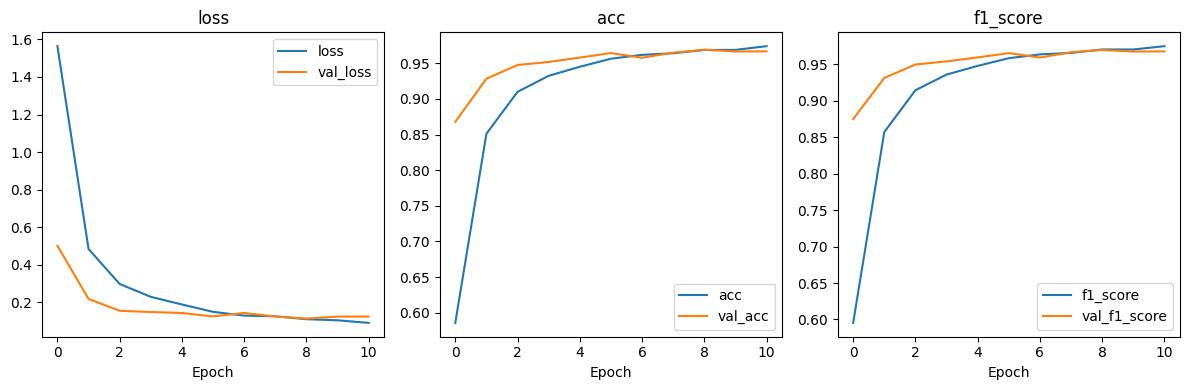

129/129 ━━━━━━━━━━━━━━━━━━━━ 31s 240ms/step - acc: 0.9725 - f1_score: 0.9737 - loss: 0.0954 - precision: 0.9768 - recall: 0.9675 - val_acc: 0.9667 - val_f1_score: 0.9679 - val_loss: 0.1247 - val_precision: 0.9701 - val_recall: 0.9655
Epoch 11: early stopping


In [43]:
from IPython.display import clear_output
records = []
for model in models:
    hist = model.fit(
        train_data,
        epochs=20,
        validation_data=validation_data,
        # steps_per_epoch=155,
        callbacks=[ Call_meback(
            save_weights=True,
            save_metrics=True,
            stop_early=True,
            name=model.name
        ),MetricsPlotter()]
    ).history

    df_hist = pd.DataFrame(hist)

    # add epoch and model columns
    df_hist["epoch"] = df_hist.index + 1
    df_hist["model"] = model.name
    
    records.append(df_hist)



In [51]:
for model in models:
    print(model)

<Functional name=MobileNetV2_head_b_256_d_128_64_d, built=True>
<Functional name=MobileNetV2_head_b_256_d_128_128_d, built=True>
<Functional name=MobileNetV2_head_b_256_256_d_128_128_d, built=True>
<Functional name=ResNet50_head_b_256_d_128_64_d, built=True>
<Functional name=ResNet50_head_b_256_d_128_128_d, built=True>
<Functional name=ResNet50_head_b_256_256_d_128_128_d, built=True>
<Functional name=EfficientNetB0_head_b_256_d_128_64_d, built=True>
<Functional name=EfficientNetB0_head_b_256_d_128_128_d, built=True>
<Functional name=EfficientNetB0_head_b_256_256_d_128_128_d, built=True>
<Functional name=EfficientNetB1_head_b_256_d_128_64_d, built=True>
<Functional name=EfficientNetB1_head_b_256_d_128_128_d, built=True>
<Functional name=EfficientNetB1_head_b_256_256_d_128_128_d, built=True>


In [61]:
pred_rec=[]
for model in models:
    hists=model.evaluate(test_data, verbose=2)
    df_pred=pd.DataFrame(hists)
    pred_rec.append(df_pred)
    
pred_rec

20/20 - 3s - 146ms/step - acc: 0.9406 - f1_score: 0.9433 - loss: 0.2052 - precision: 0.9471 - recall: 0.9351
20/20 - 3s - 141ms/step - acc: 0.9418 - f1_score: 0.9445 - loss: 0.2173 - precision: 0.9502 - recall: 0.9380
20/20 - 3s - 138ms/step - acc: 0.9341 - f1_score: 0.9368 - loss: 0.2403 - precision: 0.9425 - recall: 0.9304
20/20 - 5s - 258ms/step - acc: 0.9782 - f1_score: 0.9791 - loss: 0.0904 - precision: 0.9793 - recall: 0.9767
20/20 - 5s - 258ms/step - acc: 0.9722 - f1_score: 0.9734 - loss: 0.0947 - precision: 0.9740 - recall: 0.9698
20/20 - 5s - 258ms/step - acc: 0.9716 - f1_score: 0.9730 - loss: 0.1323 - precision: 0.9742 - recall: 0.9702
20/20 - 3s - 148ms/step - acc: 0.9647 - f1_score: 0.9666 - loss: 0.1284 - precision: 0.9682 - recall: 0.9618
20/20 - 3s - 149ms/step - acc: 0.9673 - f1_score: 0.9689 - loss: 0.1177 - precision: 0.9706 - recall: 0.9643
20/20 - 3s - 148ms/step - acc: 0.9680 - f1_score: 0.9689 - loss: 0.1465 - precision: 0.9713 - recall: 0.9653
20/20 - 4s - 201ms/

[          0
 0  0.205199
 1  0.940612
 2  0.205199
 3  0.943270
 4  0.947086
 5  0.935102,
           0
 0  0.217333
 1  0.941837
 2  0.217333
 3  0.944529
 4  0.950176
 5  0.937959,
           0
 0  0.240270
 1  0.934082
 2  0.240270
 3  0.936778
 4  0.942526
 5  0.930408,
           0
 0  0.090407
 1  0.978163
 2  0.090407
 3  0.979149
 4  0.979333
 5  0.976735,
           0
 0  0.094667
 1  0.972245
 2  0.094667
 3  0.973438
 4  0.973970
 5  0.969796,
           0
 0  0.132325
 1  0.971633
 2  0.132325
 3  0.973047
 4  0.974180
 5  0.970204,
           0
 0  0.128447
 1  0.964694
 2  0.128447
 3  0.966582
 4  0.968159
 5  0.961837,
           0
 0  0.117727
 1  0.967347
 2  0.117727
 3  0.968905
 4  0.970625
 5  0.964286,
           0
 0  0.146456
 1  0.967959
 2  0.146456
 3  0.968902
 4  0.971253
 5  0.965306,
           0
 0  0.139444
 1  0.963265
 2  0.139444
 3  0.964611
 4  0.968434
 5  0.957959,
           0
 0  0.146300
 1  0.965714
 2  0.146300
 3  0.967259
 4  0.970021
 5

In [66]:
for model in models:
    print(model.name
         )

MobileNetV2_head_b_256_d_128_64_d
MobileNetV2_head_b_256_d_128_128_d
MobileNetV2_head_b_256_256_d_128_128_d
ResNet50_head_b_256_d_128_64_d
ResNet50_head_b_256_d_128_128_d
ResNet50_head_b_256_256_d_128_128_d
EfficientNetB0_head_b_256_d_128_64_d
EfficientNetB0_head_b_256_d_128_128_d
EfficientNetB0_head_b_256_256_d_128_128_d
EfficientNetB1_head_b_256_d_128_64_d
EfficientNetB1_head_b_256_d_128_128_d
EfficientNetB1_head_b_256_256_d_128_128_d


In [73]:
import pandas as pd

# Your model names
names = [
    "MobileNetV2_head_b_256_d_128_64_d",
    "MobileNetV2_head_b_256_d_128_128_d",
    "MobileNetV2_head_b_256_256_d_128_128_d",
    "ResNet50_head_b_256_d_128_64_d",
    "ResNet50_head_b_256_d_128_128_d",
    "ResNet50_head_b_256_256_d_128_128_d",
    "EfficientNetB0_head_b_256_d_128_64_d",
    "EfficientNetB0_head_b_256_d_128_128_d",
    "EfficientNetB0_head_b_256_256_d_128_128_d",
    "EfficientNetB1_head_b_256_d_128_64_d",
    "EfficientNetB1_head_b_256_d_128_128_d",
    "EfficientNetB1_head_b_256_256_d_128_128_d",
]

# Remove first row of each DF and convert to Series
cols = [df.iloc[1:].squeeze() for df in pred_rec]

# Merge as columns
merged_df = pd.concat(cols, axis=1)
merged_df.columns = names

# Give metric row names (adjust length to match)
metric_names = ["accuracy", "f1_score", "loss", "precision", "recall"]
merged_df.index = metric_names

# Models as rows
merged_df_rows = merged_df.T
merged_df_rows.index.name = "Model"

# Output
print("\nModels as rows:\n", merged_df_rows)
merged_df_rows.to_csv("testset_f.csv", index=True)


Models as rows:
                                            accuracy  f1_score      loss  \
Model                                                                     
MobileNetV2_head_b_256_d_128_64_d          0.940612  0.205199  0.943270   
MobileNetV2_head_b_256_d_128_128_d         0.941837  0.217333  0.944529   
MobileNetV2_head_b_256_256_d_128_128_d     0.934082  0.240270  0.936778   
ResNet50_head_b_256_d_128_64_d             0.978163  0.090407  0.979149   
ResNet50_head_b_256_d_128_128_d            0.972245  0.094667  0.973438   
ResNet50_head_b_256_256_d_128_128_d        0.971633  0.132325  0.973047   
EfficientNetB0_head_b_256_d_128_64_d       0.964694  0.128447  0.966582   
EfficientNetB0_head_b_256_d_128_128_d      0.967347  0.117727  0.968905   
EfficientNetB0_head_b_256_256_d_128_128_d  0.967959  0.146456  0.968902   
EfficientNetB1_head_b_256_d_128_64_d       0.963265  0.139444  0.964611   
EfficientNetB1_head_b_256_d_128_128_d      0.965714  0.146300  0.967259   
Efficie

In [92]:
names=df_data.Folder
names=names[0:-1]
list_of_cm=[]
for model in models:
    preds=model.predict(test_data)
    preds=np.argmax(preds,1)
    y = np.concatenate([y for x, y in test_data], axis=0)
    y_true=np.argmax(y,1)
    cm=confusion_matrix(y_true,preds,normalize='pred')
    cm_df=pd.DataFrame(cm,index=names,columns=names)
    list_of_cm.append(cm_df)
    cm_df.to_csv("cm"+ model.name,index=True)

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 310ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 145ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 307ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 488ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 492ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 489ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 487ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 490ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 488ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 22s 657ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 22s 660ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 22s 663ms/step


In [76]:
preds=models[1].predict(test_data)
preds=np.argmax(preds,1)
y = np.concatenate([y for x, y in test_data], axis=0)
y_true=np.argmax(y,1)    

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 209ms/step


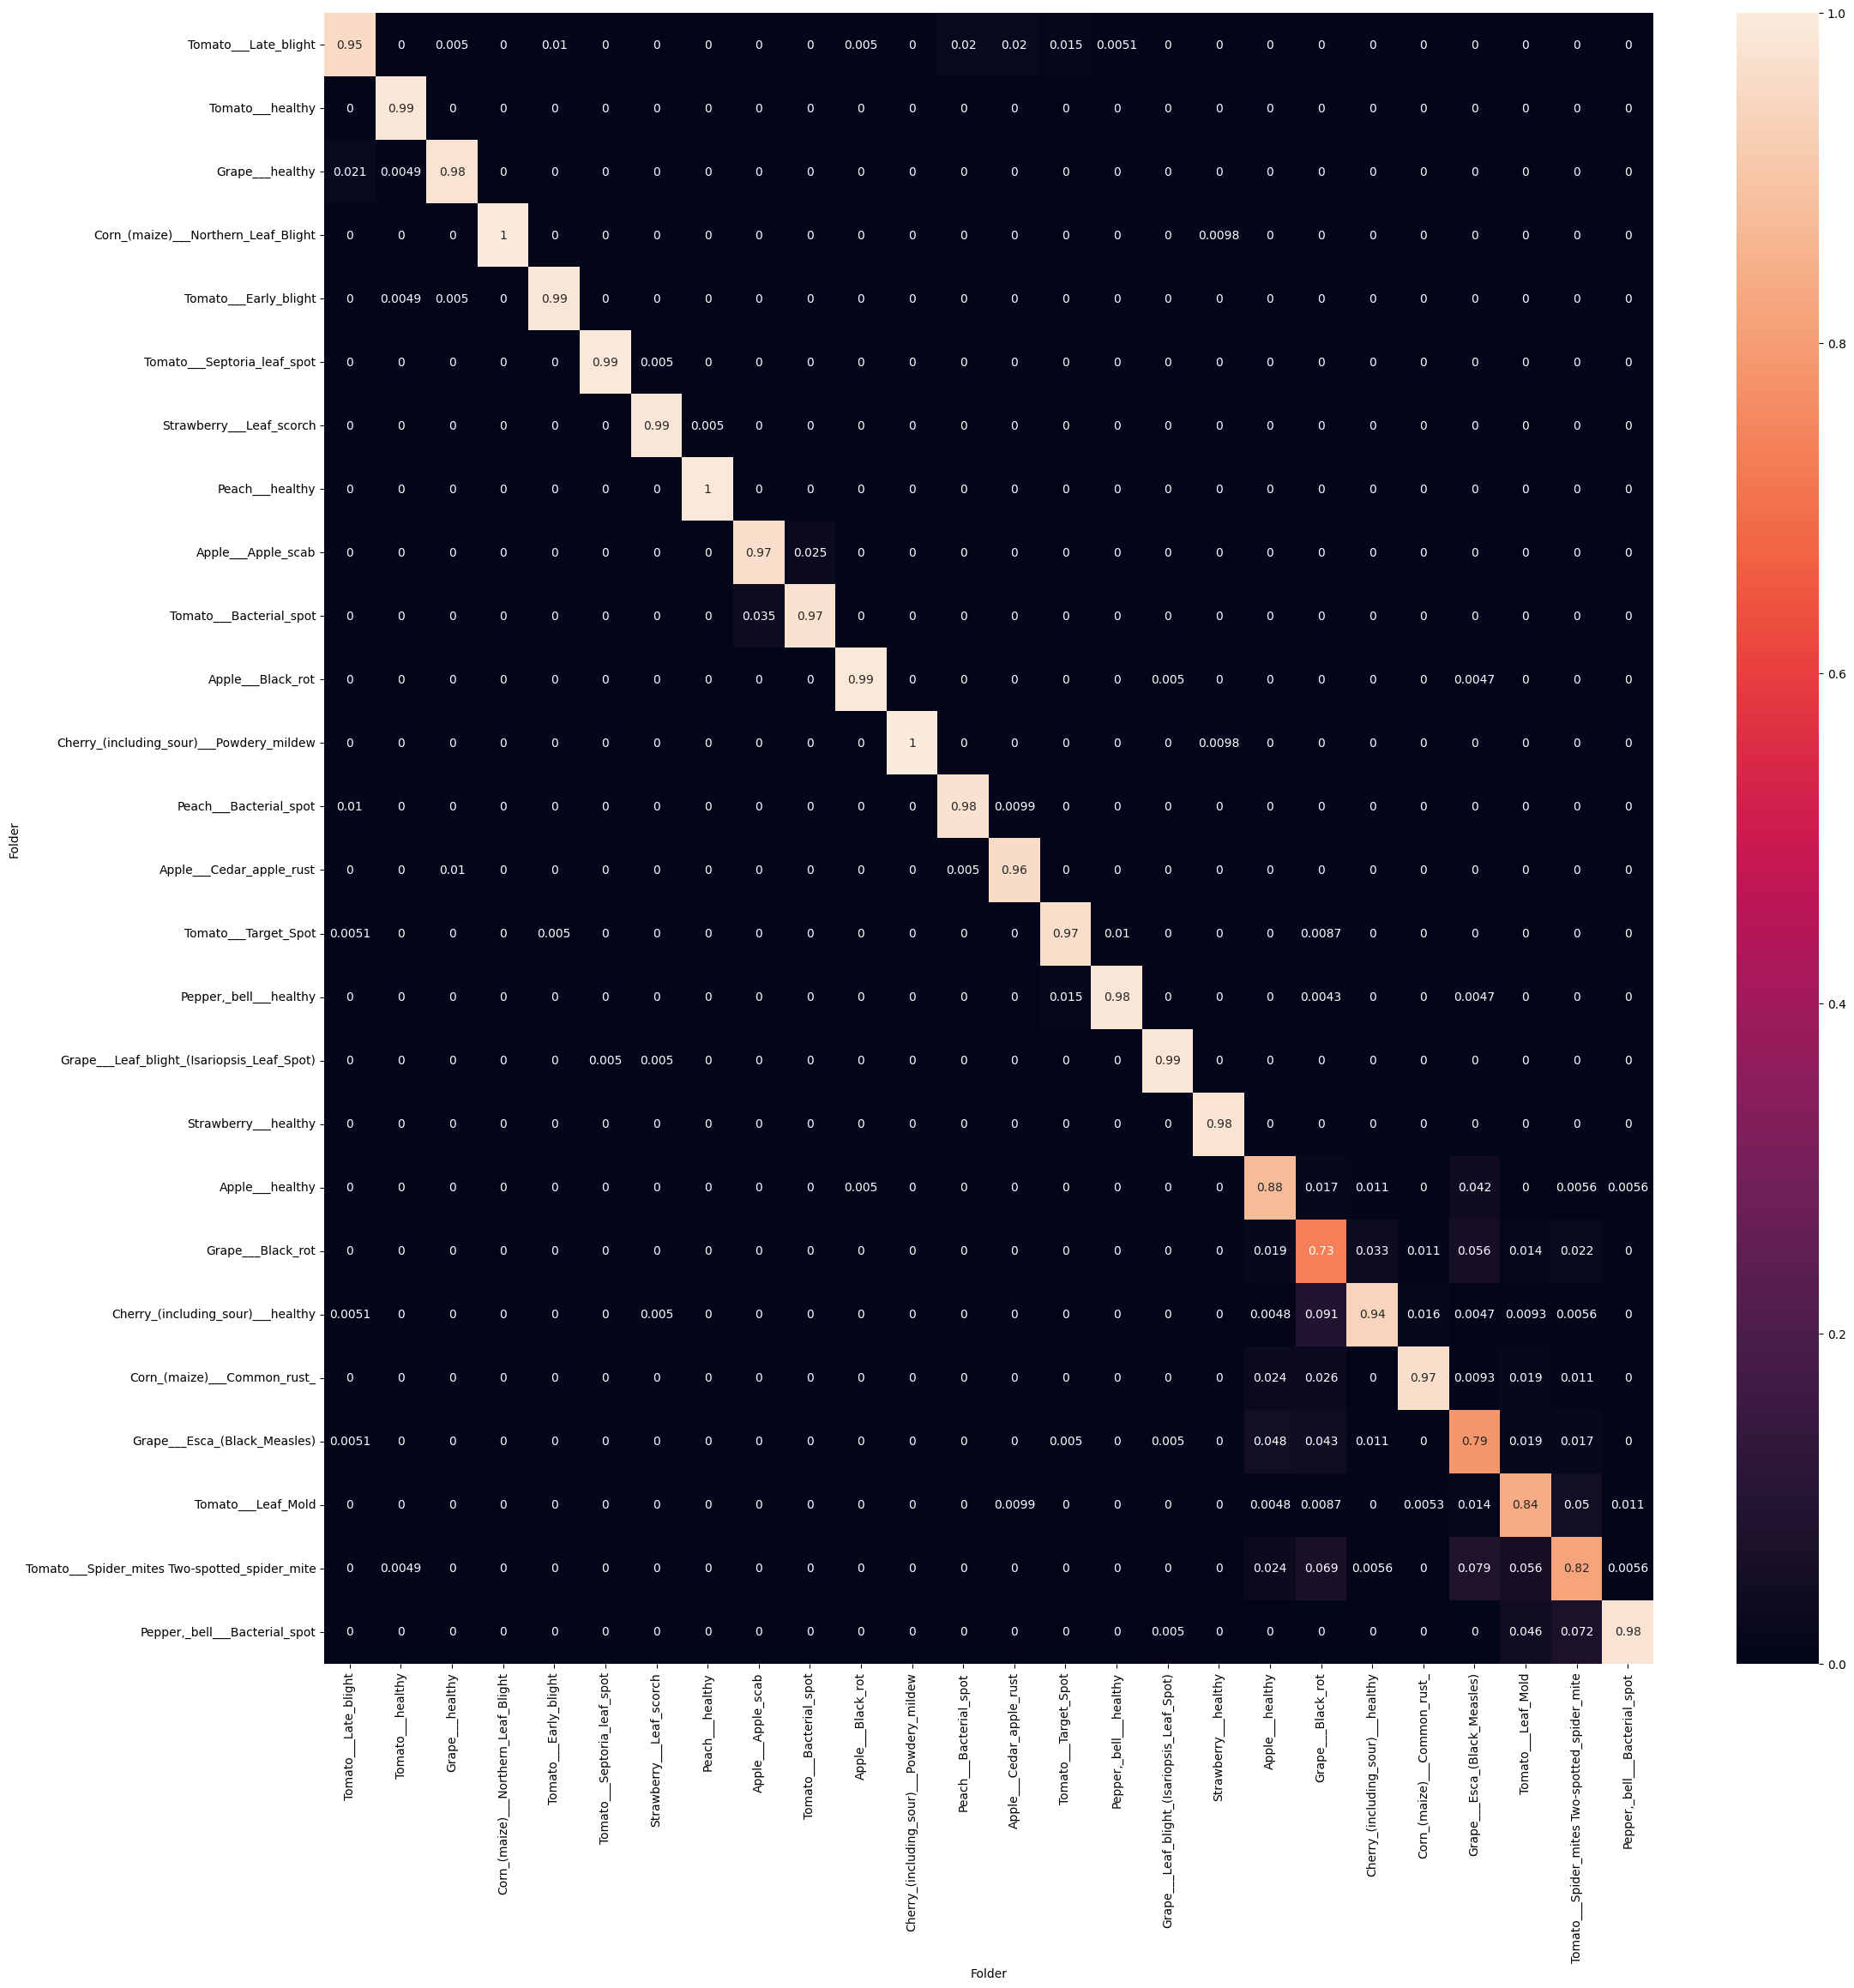

In [88]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
names=df_data.Folder
names=names[0:-1]
names

cm=confusion_matrix(y_true,preds,normalize='pred')
cm_df=pd.DataFrame(cm,index=names,columns=names)
cm_df.to_csv("_head_b_256_d_128_128_d.csv", index=True)

figure=plt.figure(figsize=(25,25))
sns.heatmap(cm_df,annot=True)
plt.show()

In [74]:
df_data,files=parse_root('/kaggle/input/plantvillage-dataset/color')

Mean: 1170, Half Mean: 585


In [48]:
wide_df = pd.concat(records, ignore_index=True)
wide_df


,acc,f1_score,loss,precision,recall,val_acc,val_f1_score,val_loss,val_precision,val_recall,epoch,model
0,0.429507,0.430585,1.936032,0.788198,0.269302,0.858571,0.864235,0.610148,0.967140,0.666735,1,MobileNetV2_head_b_256_d_128_64_d
1,0.741053,0.747667,0.847731,0.862448,0.645844,0.907143,0.911469,0.301958,0.943883,0.858163,2,MobileNetV2_head_b_256_d_128_64_d
2,0.817897,0.823708,0.590301,0.893224,0.754424,0.917347,0.921506,0.246931,0.937099,0.893878,3,MobileNetV2_head_b_256_d_128_64_d
3,0.859318,0.864325,0.455630,0.912568,0.812536,0.924898,0.927885,0.221302,0.941238,0.912041,4,MobileNetV2_head_b_256_d_128_64_d
4,0.884476,0.889285,0.380045,0.927239,0.846526,0.930204,0.932582,0.208916,0.941472,0.919184,5,MobileNetV2_head_b_256_d_128_64_d
...,...,...,...,...,...,...,...,...,...,...,...,...
116,0.961807,0.963722,0.129560,0.970710,0.952852,0.957755,0.959404,0.143512,0.961018,0.955918,7,EfficientNetB1_head_b_256_256_d_128_128_d
117,0.964030,0.965801,0.126047,0.972537,0.955593,0.964898,0.966668,0.124952,0.967815,0.963469,8,EfficientNetB1_head_b_256_256_d_128_128_d
118,0.968690,0.970463,0.110443,0.976096,0.961380,0.968980,0.969829,0.113663,0.971130,0.967959,9,EfficientNetB1_head_b_256_256_d_128_128_d
119,0.968781,0.970466,0.104644,0.975857,0.962720,0.966531,0.967620,0.124384,0.968840,0.964490,10,EfficientNetB1_head_b_256_256_d_128_128_d


In [49]:
wide_df.to_csv("Group_f_lr_0.001_.csv", index=False)

acc


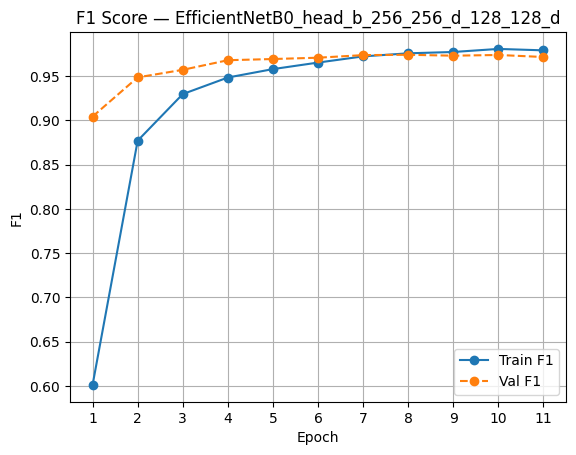

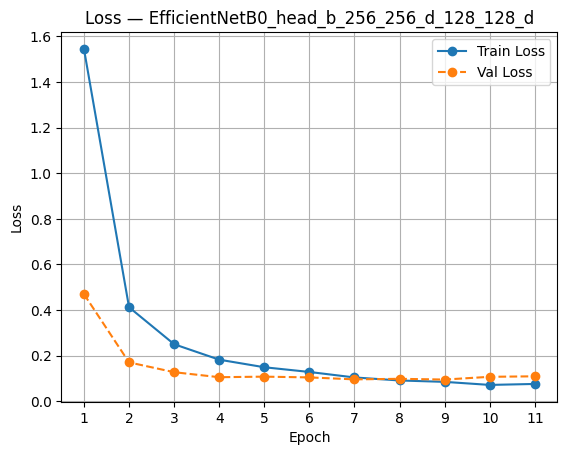

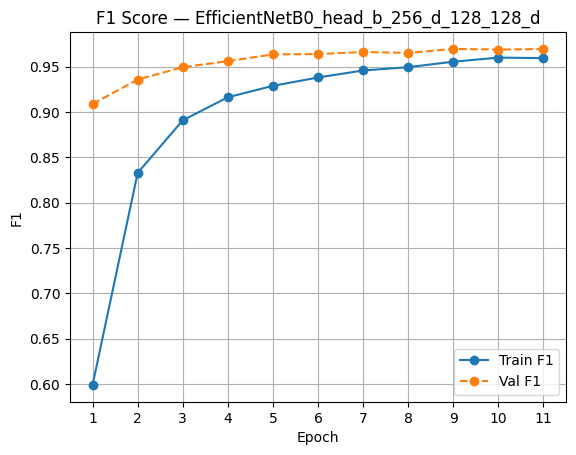

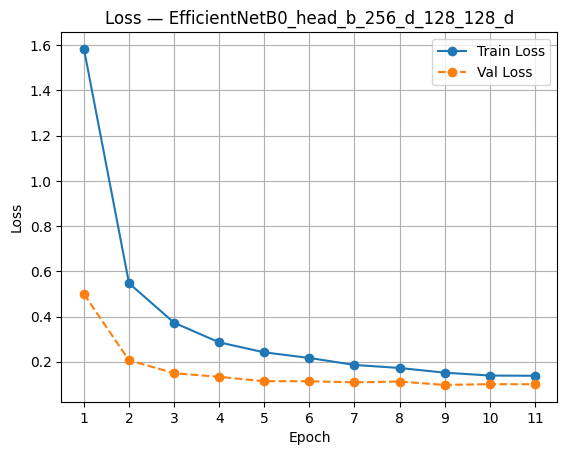

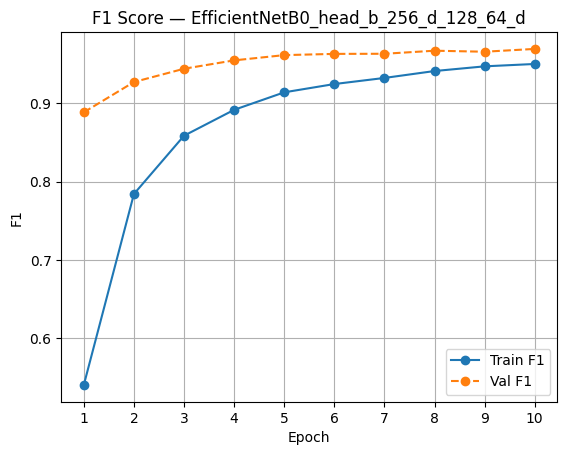

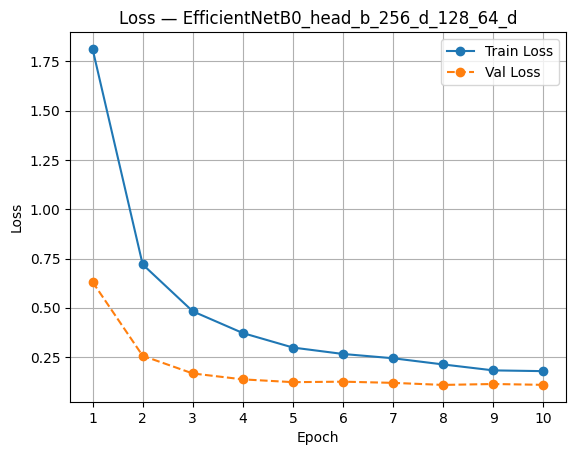

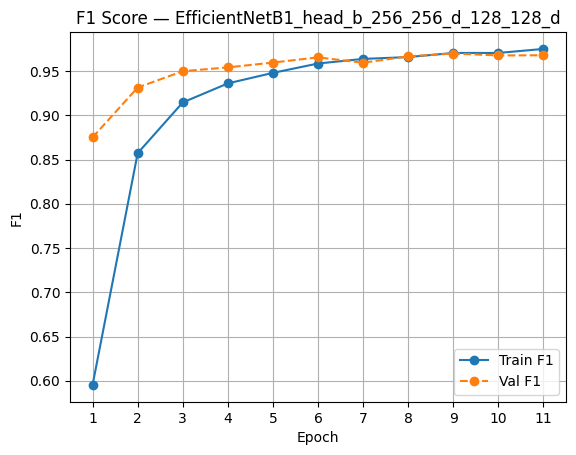

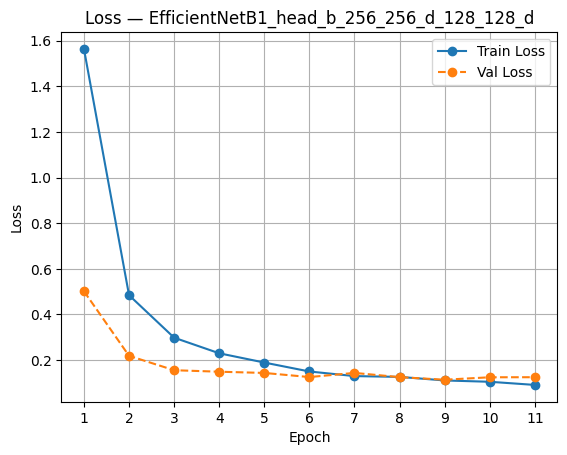

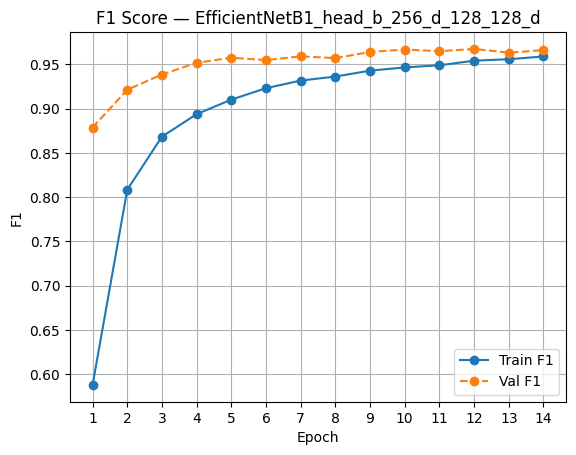

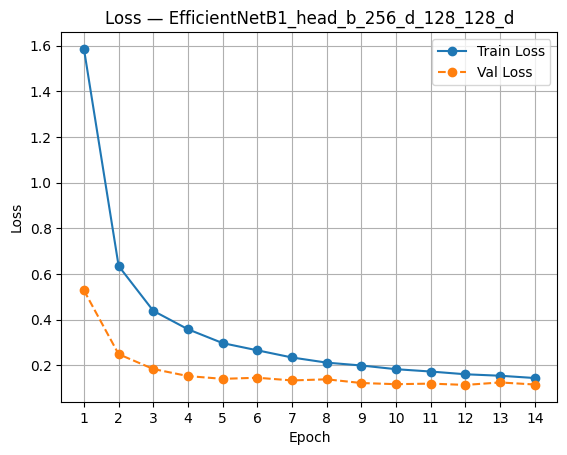

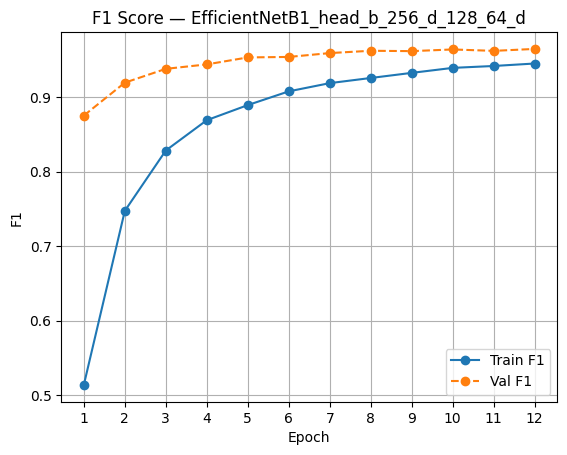

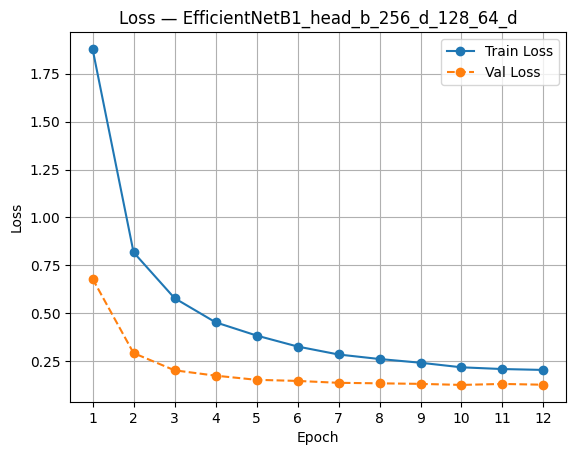

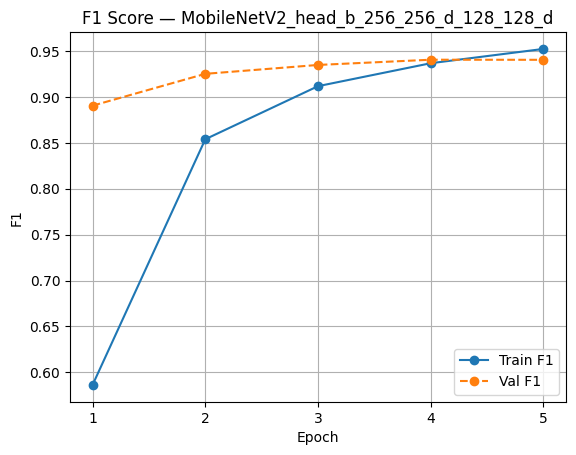

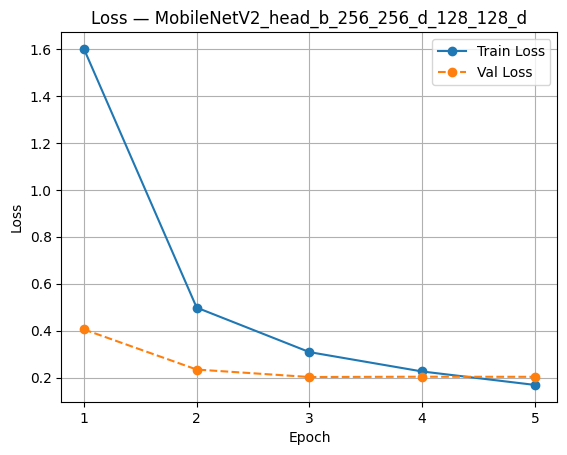

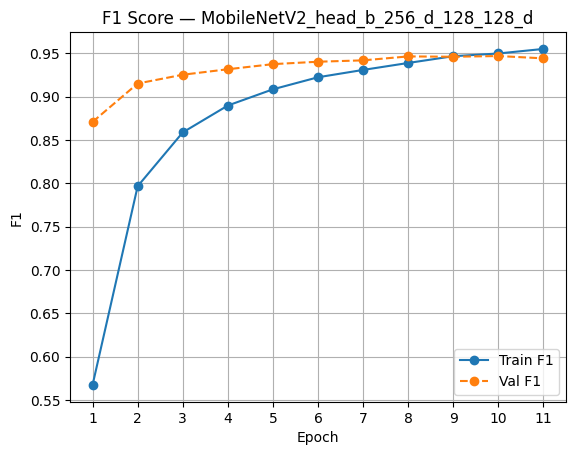

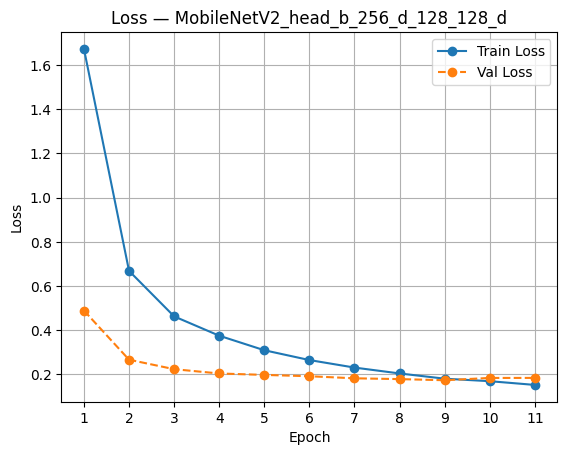

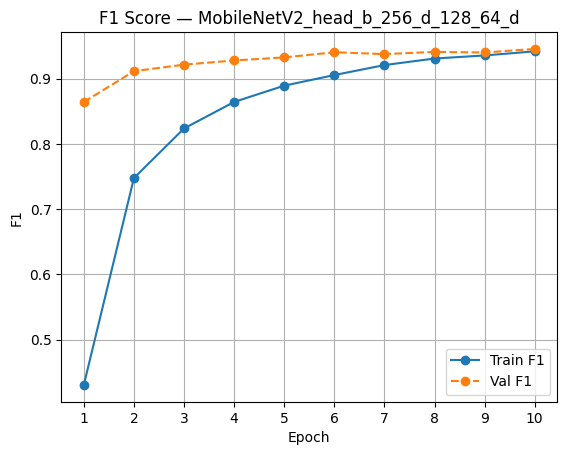

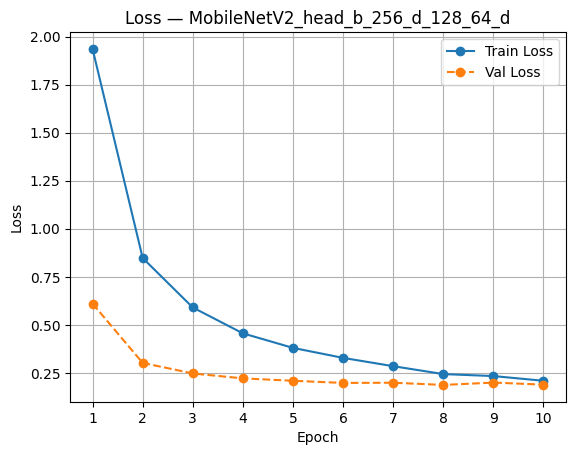

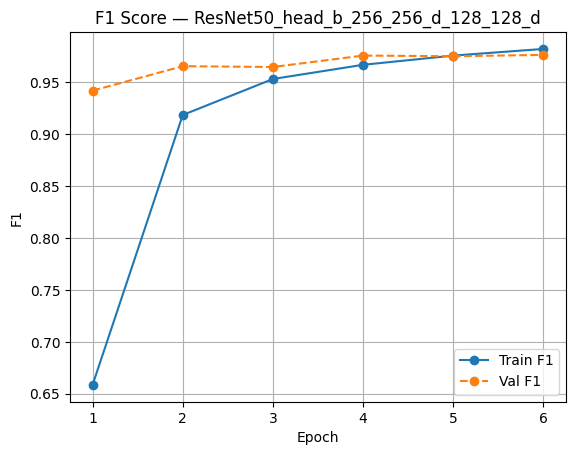

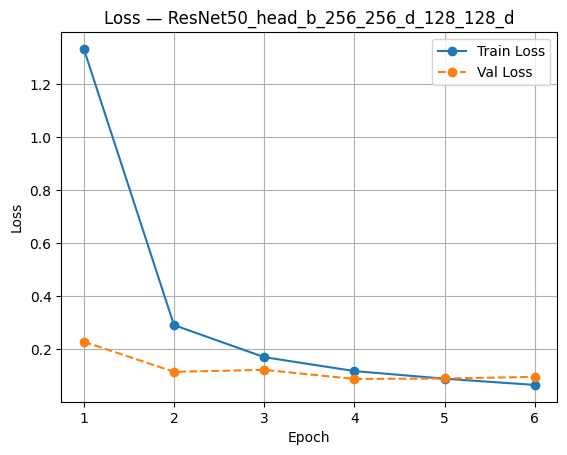

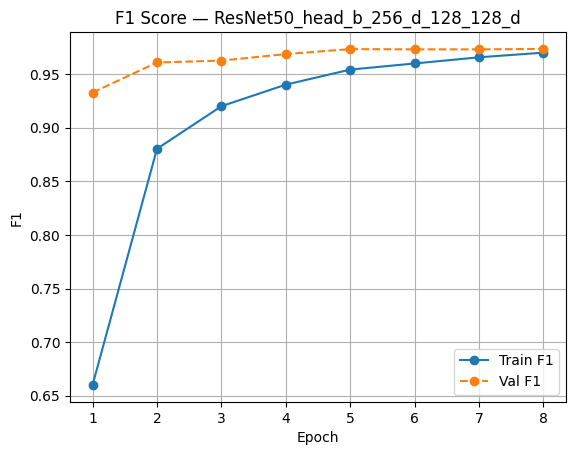

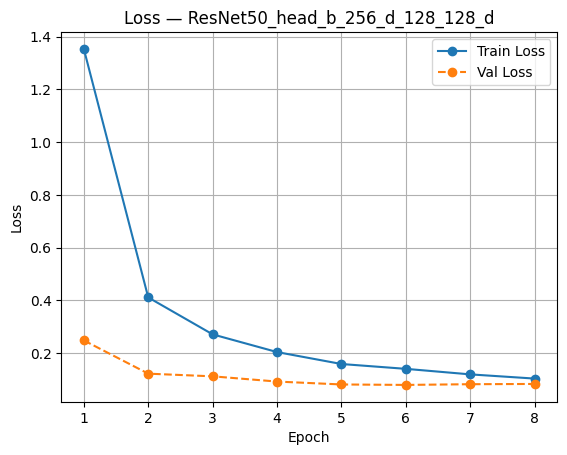

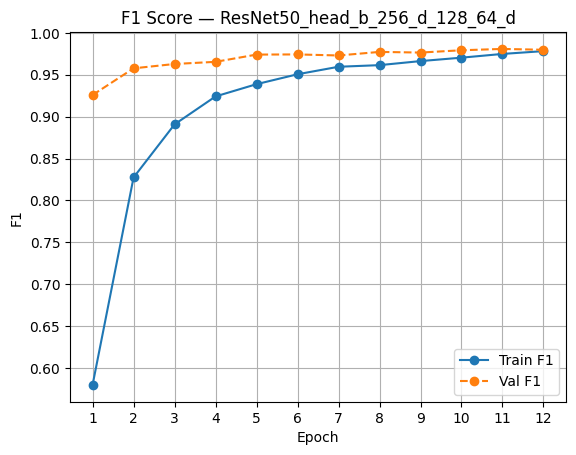

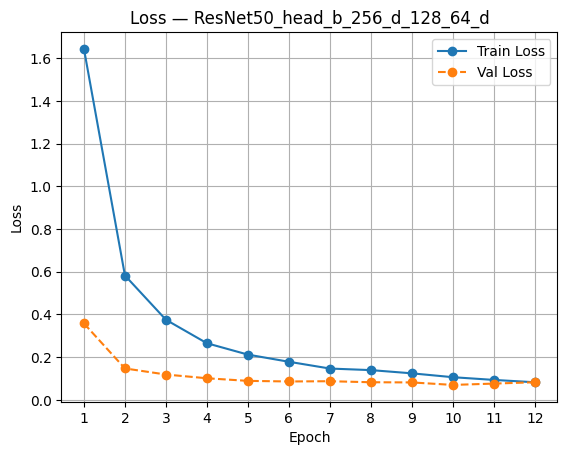

In [93]:
import matplotlib.pyplot as plt

# assumes df has: model, epoch, f1_score, val_f1_score, loss, val_loss
for model, g in wide_df.groupby("model"):
    g = g.sort_values("epoch")
    epochs = g["epoch"]

    # F1
    plt.figure()
    plt.plot(epochs, g["f1_score"], marker="o", label="Train F1")
    plt.plot(epochs, g["val_f1_score"], marker="o", linestyle="--", label="Val F1")
    plt.title(f"F1 Score — {model}")
    plt.xlabel("Epoch"); plt.ylabel("F1"); plt.xticks(epochs); plt.grid(True); plt.legend()
    plt.show()

    # Loss
    plt.figure()
    plt.plot(epochs, g["loss"], marker="o", label="Train Loss")
    plt.plot(epochs, g["val_loss"], marker="o", linestyle="--", label="Val Loss")
    plt.title(f"Loss — {model}")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.xticks(epochs); plt.grid(True); plt.legend()
    plt.show()
